# Revision Analyses

All new analyses required by the revision plan:
1. Conditional Transfer Entropy (CTE) — MAJOR-3a
2. A/K₀ ratio sweep — MAJOR-3b
3. Omega sweep for inset — MINOR-4
4. Regenerate all original figures for the paper

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from scipy.stats import t as student_t
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import os

# ── Core defaults ──
SEED = 42
rng_global = np.random.default_rng(SEED)
N = 1000
T = 10_000
discard = 1000
K0 = 100.0
r_min, r_max = 3.9, 4.0
BINS_DEFAULT = 15
LAG_K_DEFAULT = 2

FIGDIR = os.path.join(os.getcwd(), 'figures')
os.makedirs(FIGDIR, exist_ok=True)

# ── Modulators ──
def K_sinusoid(n, K0=100.0, A=25.0, omega=2*np.pi/2000):
    return K0 + A * np.sin(omega * n)

def K_logistic(n, K0=100.0, A=25.0, k=0.002, n0=5000):
    return K0 + A / (1.0 + np.exp(-k * (n - n0)))

def K_invlogistic(n, K0=100.0, A=25.0, k=0.002, n0=5000):
    return K0 + A / (1.0 + np.exp(+k * (n - n0)))

def logistic_step(x, r, K):
    return r * x * (1 - x / K)

# ── Simulators ──
def simulate_full_population(mod_fn, N=N, T=T, K0=K0, r_min=r_min, r_max=r_max, seed=None):
    rng = np.random.default_rng(seed)
    x = np.full(N, 0.1)
    r = rng.uniform(r_min, r_max, N)
    X_all = np.zeros((N, T))
    K_series = np.zeros(T)
    for n in range(T):
        K_n = mod_fn(n)
        K_series[n] = K_n
        x = logistic_step(x, r, K_n)
        x = np.clip(x, 0, 2 * K0)
        X_all[:, n] = x
    return X_all, K_series

def simulate_mean_and_unit(mod_fn, N=N, T=T, discard=discard, K0=K0,
                           r_min=r_min, r_max=r_max, seed=None):
    rng = np.random.default_rng(seed)
    x = np.full(N, 0.1)
    r = rng.uniform(r_min, r_max, N)
    M, x0, clip_frac = [], [], []
    for n in range(T):
        K_n = mod_fn(n)
        x = logistic_step(x, r, K_n)
        x = np.clip(x, 0, 2 * K0)
        if n >= discard:
            M.append(np.mean(x))
            x0.append(x[0])
            clip_frac.append(np.mean(x >= 2 * K0))
    return np.array(M), np.array(x0), np.array(clip_frac)

def simulate_mean_unit_and_K(mod_fn, N=N, T=T, discard=discard, K0=K0,
                              r_min=r_min, r_max=r_max, seed=None):
    """Like simulate_mean_and_unit but also returns K_n series."""
    rng = np.random.default_rng(seed)
    x = np.full(N, 0.1)
    r = rng.uniform(r_min, r_max, N)
    M, x0, K_vals = [], [], []
    for n in range(T):
        K_n = mod_fn(n)
        x = logistic_step(x, r, K_n)
        x = np.clip(x, 0, 2 * K0)
        if n >= discard:
            M.append(np.mean(x))
            x0.append(x[0])
            K_vals.append(K_n)
    return np.array(M), np.array(x0), np.array(K_vals)

# ── TE ──
def transfer_entropy_lagged(source, target, k=LAG_K_DEFAULT, bins=BINS_DEFAULT):
    source = np.asarray(source); target = np.asarray(target)
    if k <= 0 or k >= len(target):
        raise ValueError('k must be >= 1 and < len(series)')
    tp = target[:-k]; tf = target[k:]; sp = source[:-k]
    t_edges = np.histogram(np.r_[tp, tf], bins=bins)[1]
    s_edges = np.histogram(sp, bins=bins)[1]
    tf_b = np.clip(np.digitize(tf, t_edges) - 1, 0, bins - 1)
    tp_b = np.clip(np.digitize(tp, t_edges) - 1, 0, bins - 1)
    sp_b = np.clip(np.digitize(sp, s_edges) - 1, 0, bins - 1)
    joint_tp_sp = tp_b * bins + sp_b
    te_nat = mutual_info_score(tf_b, joint_tp_sp) - mutual_info_score(tf_b, tp_b)
    return te_nat / np.log(2.0)

# ── Conditional TE ──
def conditional_transfer_entropy(source, target, condition, k=LAG_K_DEFAULT, bins=BINS_DEFAULT):
    """
    CTE(source -> target | condition)
    = H(target_future | target_past, condition_past)
      - H(target_future | target_past, source_past, condition_past)
    """
    source = np.asarray(source); target = np.asarray(target); condition = np.asarray(condition)
    L = min(len(source), len(target), len(condition))
    source = source[:L]; target = target[:L]; condition = condition[:L]
    tp = target[:-k]; tf = target[k:]; sp = source[:-k]; cp = condition[:-k]
    t_edges = np.histogram(np.r_[tp, tf], bins=bins)[1]
    s_edges = np.histogram(sp, bins=bins)[1]
    c_edges = np.histogram(cp, bins=bins)[1]
    tf_b = np.clip(np.digitize(tf, t_edges) - 1, 0, bins - 1)
    tp_b = np.clip(np.digitize(tp, t_edges) - 1, 0, bins - 1)
    sp_b = np.clip(np.digitize(sp, s_edges) - 1, 0, bins - 1)
    cp_b = np.clip(np.digitize(cp, c_edges) - 1, 0, bins - 1)
    joint_tp_cp = tp_b * bins + cp_b
    joint_tp_sp_cp = tp_b * (bins * bins) + sp_b * bins + cp_b
    cte_nat = mutual_info_score(tf_b, joint_tp_sp_cp) - mutual_info_score(tf_b, joint_tp_cp)
    return cte_nat / np.log(2.0)

# ── Helpers ──
def mean_ci(arr_1d, alpha=0.05):
    arr = np.asarray(arr_1d, dtype=float)
    m = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(len(arr))
    h = student_t.ppf(1 - alpha/2, df=len(arr)-1) * se if len(arr) > 1 else 0.0
    return m, h

def logistic_curve(A, L, k, A0):
    return L / (1.0 + np.exp(-k * (A - A0)))

def fit_logistic_and_r2(x, y, p0=None, bounds=([0.0, 0.0, 0.0], [5.0, 5.0, 60.0]), maxfev=20000):
    if p0 is None:
        p0 = [max(0.1, np.max(y)), 0.1, np.median(x)]
    popt, _ = curve_fit(logistic_curve, x, y, p0=p0, bounds=bounds, maxfev=maxfev)
    y_fit = logistic_curve(x, *popt)
    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1.0 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return popt, r2

# ── Surrogate helpers (used in Fig 3) ──
def circular_shift_surrogate(series, seed=None, min_shift=10):
    rng = np.random.default_rng(seed)
    Tlen = len(series)
    if Tlen <= 1: return series.copy()
    shift = rng.integers(min_shift, Tlen - min_shift) if Tlen > 2*min_shift else rng.integers(1, Tlen)
    return np.roll(series, shift)

def surrogate_te_array(source, target, n_surrogates=100, seed=None, k=LAG_K_DEFAULT, bins=BINS_DEFAULT):
    rng = np.random.default_rng(seed)
    vals = np.empty(n_surrogates, dtype=float)
    for s in range(n_surrogates):
        src_surr = circular_shift_surrogate(source, seed=rng.integers(1 << 30))
        vals[s] = transfer_entropy_lagged(src_surr, target, k=k, bins=bins)
    return vals

def empirical_p_value(te_obs, te_surr):
    return (1 + np.sum(te_surr >= te_obs)) / (1 + len(te_surr))

# ── Uncoupled simulator with clip tracking ──
def simulate_uncoupled_K_modulated(N=N, K0=K0, A=25, omega=2*np.pi/2000,
                                   timesteps=T, discard=discard,
                                   r_min=r_min, r_max=r_max, seed=None):
    rng = np.random.default_rng(seed)
    x = np.full(N, 0.1)
    r = rng.uniform(r_min, r_max, N)
    mean_field, local_series = [], []
    lower_clip_count = 0; upper_clip_count = 0; steps_with_any_clip = 0; T_eff = 0
    for n in range(timesteps):
        K_n = K_sinusoid(n, K0=K0, A=A, omega=omega)
        x_next = logistic_step(x, r, K_n)
        if n >= discard:
            low_hits = np.sum(x_next <= 0); high_hits = np.sum(x_next >= 2 * K0)
            lower_clip_count += int(low_hits); upper_clip_count += int(high_hits)
            steps_with_any_clip += int((low_hits + high_hits) > 0); T_eff += N
        x = np.clip(x_next, 0, 2 * K0)
        if n >= discard:
            mean_field.append(np.mean(x)); local_series.append(x[0])
    clip_counts = {'lower': lower_clip_count, 'upper': upper_clip_count,
                   'total_points': T_eff, 'steps_with_any_clip': steps_with_any_clip}
    return np.array(mean_field), np.array(local_series), clip_counts

n_seeds = 10  # global seed count for sweeps
print('Setup complete.')

Setup complete.


## Figure 1A — Time series under sinusoidal modulation

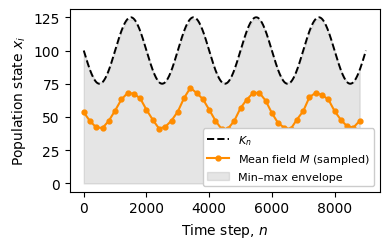

In [2]:
A = 25
sample_every = 200
mod_fn = lambda n: K_sinusoid(n, K0=K0, A=A)
X_all, K_t = simulate_full_population(mod_fn, N=N, T=T, K0=K0,
                                      r_min=r_min, r_max=r_max, seed=SEED)
X_all_d = X_all[:, discard:]
K_t_d = K_t[discard:]
T_eff = X_all_d.shape[1]
sample_indices = np.arange(0, T_eff, sample_every)
X_sampled = X_all_d[:, sample_indices]
mean_sampled = X_sampled.mean(axis=0)
min_sampled = X_sampled.min(axis=0)
max_sampled = X_sampled.max(axis=0)

plt.figure(figsize=(4, 2.6))
plt.plot(np.arange(len(K_t_d)), K_t_d, color='black', lw=1.4, ls='--', label=r'$K_n$')
plt.plot(sample_indices, mean_sampled, '-o', ms=3.5, color='darkorange',
         label=r'Mean field $M$ (sampled)')
plt.fill_between(sample_indices, min_sampled, max_sampled,
                 color='gray', alpha=0.2, label='Min–max envelope')
plt.xlabel('Time step, $n$')
plt.ylabel('Population state $x_i$')
plt.legend(loc='lower right', fontsize=8, facecolor='white', framealpha=1)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig1a.png'), dpi=300)
plt.show()

## Figure 1B — TE amplitude sweep with ω inset (MINOR-4)

Computing omega sweep for inset...


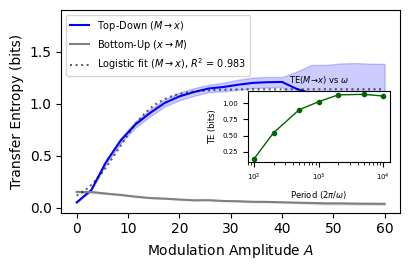

In [3]:
# Main amplitude sweep
A_vals = np.linspace(0, 60, 22)
te_td_all, te_bu_all = [], []
for A in A_vals:
    td_seeds, bu_seeds = [], []
    for i in range(n_seeds):
        M, X, _ = simulate_uncoupled_K_modulated(A=A, seed=SEED + i)
        td = transfer_entropy_lagged(M, X, k=LAG_K_DEFAULT, bins=BINS_DEFAULT)
        bu = transfer_entropy_lagged(X, M, k=LAG_K_DEFAULT, bins=BINS_DEFAULT)
        td_seeds.append(td); bu_seeds.append(bu)
    te_td_all.append(td_seeds); te_bu_all.append(bu_seeds)

td_mean, td_ci = zip(*[mean_ci(vals) for vals in te_td_all])
bu_mean, bu_ci = zip(*[mean_ci(vals) for vals in te_bu_all])
td_mean, td_ci = np.array(td_mean), np.array(td_ci)
bu_mean, bu_ci = np.array(bu_mean), np.array(bu_ci)
popt, r2 = fit_logistic_and_r2(A_vals, td_mean)
A_fit = np.linspace(0, 60, 200)

# Omega sweep (MINOR-4)
print('Computing omega sweep for inset...')
omega_vals = np.array([2*np.pi/10000, 2*np.pi/5000, 2*np.pi/2000, 2*np.pi/1000,
                       2*np.pi/500, 2*np.pi/200, 2*np.pi/100])
omega_periods = (2*np.pi) / omega_vals
te_omega_td = []
for omega in omega_vals:
    td_seeds = []
    for i in range(n_seeds):
        M, X, _ = simulate_uncoupled_K_modulated(A=25, omega=omega, seed=SEED + i)
        td = transfer_entropy_lagged(M, X, k=LAG_K_DEFAULT, bins=BINS_DEFAULT)
        td_seeds.append(td)
    te_omega_td.append(np.mean(td_seeds))
te_omega_td = np.array(te_omega_td)

# Plot
fig, ax = plt.subplots(figsize=(4.2, 2.8))
ax.plot(A_vals, td_mean, label=r'Top-Down ($M \rightarrow x$)', color='blue')
ax.fill_between(A_vals, td_mean - td_ci, td_mean + td_ci, color='blue', alpha=0.2)
ax.plot(A_vals, bu_mean, label=r'Bottom-Up ($x \rightarrow M$)', color='gray', linestyle='-')
ax.fill_between(A_vals, bu_mean - bu_ci, bu_mean + bu_ci, color='gray', alpha=0.2)
ax.plot(A_fit, logistic_curve(A_fit, *popt), color='black', ls=':', alpha=0.6,
        label=f'Logistic fit ($M\\rightarrow x$), $R^2$ = {r2:.3f}')
ax.set_xlabel('Modulation Amplitude $A$', fontsize=10)
ax.set_ylabel('Transfer Entropy (bits)', fontsize=10)
ax.legend(loc='upper left', fontsize=7)
ax.set_ylim(-0.05, 1.9)

# Inset: omega
axin = ax.inset_axes([0.55, 0.25, 0.42, 0.35])
axin.plot(omega_periods, te_omega_td, 'o-', color='darkgreen', ms=3, lw=1)
axin.set_xlabel(r'Period ($2\pi/\omega$)', fontsize=6)
axin.set_ylabel('TE (bits)', fontsize=6)
axin.tick_params(labelsize=5)
axin.set_xscale('log')
axin.set_title(r'TE($M\!\rightarrow\!x$) vs $\omega$', fontsize=6)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'fig1b.png'), dpi=300)
plt.show()

## Figure 4 — Conditional Transfer Entropy (MAJOR-3a)

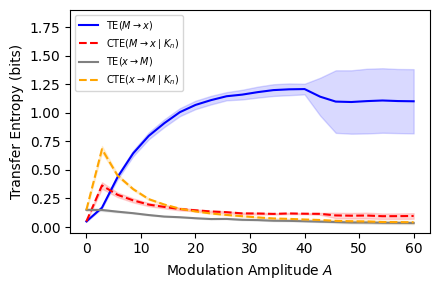

At A=60: TE(M->x)=1.1008, CTE(M->x|K)=0.0966
CTE/TE ratio at A=60: 0.088  (reduction: 91.2%)


In [4]:
A_vals_cte = np.linspace(0, 60, 22)
n_seeds_cte = 10

te_td_unc, te_td_cte_arr = [], []
te_bu_unc, te_bu_cte_arr = [], []

for A in A_vals_cte:
    td_unc_seeds, td_cte_seeds = [], []
    bu_unc_seeds, bu_cte_seeds = [], []
    for i in range(n_seeds_cte):
        mod_fn_i = lambda n, A=A: K_sinusoid(n, K0=K0, A=A)
        M, x0, K_series = simulate_mean_unit_and_K(mod_fn_i, N=N, T=T, discard=discard,
                                                    K0=K0, r_min=r_min, r_max=r_max, seed=SEED+i)
        td_unc = transfer_entropy_lagged(M, x0, k=LAG_K_DEFAULT, bins=BINS_DEFAULT)
        bu_unc = transfer_entropy_lagged(x0, M, k=LAG_K_DEFAULT, bins=BINS_DEFAULT)
        td_cte = conditional_transfer_entropy(M, x0, K_series, k=LAG_K_DEFAULT, bins=BINS_DEFAULT)
        bu_cte = conditional_transfer_entropy(x0, M, K_series, k=LAG_K_DEFAULT, bins=BINS_DEFAULT)
        td_unc_seeds.append(td_unc); td_cte_seeds.append(td_cte)
        bu_unc_seeds.append(bu_unc); bu_cte_seeds.append(bu_cte)
    te_td_unc.append(td_unc_seeds); te_td_cte_arr.append(td_cte_seeds)
    te_bu_unc.append(bu_unc_seeds); te_bu_cte_arr.append(bu_cte_seeds)

td_unc_m, td_unc_ci = zip(*[mean_ci(v) for v in te_td_unc])
td_cte_m, td_cte_ci = zip(*[mean_ci(v) for v in te_td_cte_arr])
bu_unc_m, bu_unc_ci = zip(*[mean_ci(v) for v in te_bu_unc])
bu_cte_m, bu_cte_ci = zip(*[mean_ci(v) for v in te_bu_cte_arr])
td_unc_m = np.array(td_unc_m); td_unc_ci = np.array(td_unc_ci)
td_cte_m = np.array(td_cte_m); td_cte_ci = np.array(td_cte_ci)
bu_unc_m = np.array(bu_unc_m); bu_unc_ci = np.array(bu_unc_ci)
bu_cte_m = np.array(bu_cte_m); bu_cte_ci = np.array(bu_cte_ci)

fig, ax = plt.subplots(figsize=(4.5, 3))
ax.plot(A_vals_cte, td_unc_m, '-', color='blue', label=r'TE($M \rightarrow x$)')
ax.fill_between(A_vals_cte, td_unc_m - td_unc_ci, td_unc_m + td_unc_ci, color='blue', alpha=0.15)
ax.plot(A_vals_cte, td_cte_m, '--', color='red', label=r'CTE($M \rightarrow x \mid K_n$)')
ax.fill_between(A_vals_cte, td_cte_m - td_cte_ci, td_cte_m + td_cte_ci, color='red', alpha=0.15)
ax.plot(A_vals_cte, bu_unc_m, '-', color='gray', label=r'TE($x \rightarrow M$)')
ax.fill_between(A_vals_cte, bu_unc_m - bu_unc_ci, bu_unc_m + bu_unc_ci, color='gray', alpha=0.15)
ax.plot(A_vals_cte, bu_cte_m, '--', color='orange', label=r'CTE($x \rightarrow M \mid K_n$)')
ax.fill_between(A_vals_cte, bu_cte_m - bu_cte_ci, bu_cte_m + bu_cte_ci, color='orange', alpha=0.15)
ax.set_xlabel('Modulation Amplitude $A$', fontsize=10)
ax.set_ylabel('Transfer Entropy (bits)', fontsize=10)
ax.legend(loc='upper left', fontsize=7)
ax.set_ylim(-0.05, 1.9)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'fig_cte.png'), dpi=300)
plt.show()

# Summary
ratio_cte_te = td_cte_m[-1] / td_unc_m[-1] if td_unc_m[-1] > 0 else 0
print(f'At A=60: TE(M->x)={td_unc_m[-1]:.4f}, CTE(M->x|K)={td_cte_m[-1]:.4f}')
print(f'CTE/TE ratio at A=60: {ratio_cte_te:.3f}  (reduction: {(1-ratio_cte_te)*100:.1f}%)')

## Figure 5 — A/K₀ ratio sweep (MAJOR-3b)

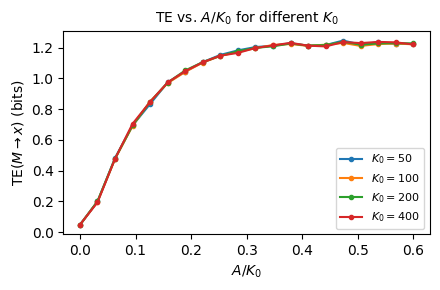

In [5]:
K0_vals = [50, 100, 200, 400]
A_over_K0_vals = np.linspace(0, 0.6, 20)
n_seeds_ratio = 5

fig, ax = plt.subplots(figsize=(4.5, 3))
colors_ratio = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for kidx, K0_val in enumerate(K0_vals):
    te_td_ratio = []
    for ratio in A_over_K0_vals:
        A_val = ratio * K0_val
        td_seeds = []
        for i in range(n_seeds_ratio):
            mod_fn = lambda n, A=A_val, K0v=K0_val: K0v + A * np.sin(2*np.pi/2000 * n)
            M, x0, _ = simulate_mean_and_unit(mod_fn, N=N, T=T, discard=discard,
                                               K0=K0_val, r_min=r_min, r_max=r_max, seed=SEED+i)
            td = transfer_entropy_lagged(M, x0, k=LAG_K_DEFAULT, bins=BINS_DEFAULT)
            td_seeds.append(td)
        te_td_ratio.append(np.mean(td_seeds))
    te_td_ratio = np.array(te_td_ratio)
    ax.plot(A_over_K0_vals, te_td_ratio, '-o', ms=3, color=colors_ratio[kidx],
            label=f'$K_0={K0_val}$')

ax.set_xlabel('$A / K_0$', fontsize=10)
ax.set_ylabel(r'TE($M \rightarrow x$) (bits)', fontsize=10)
ax.legend(fontsize=8)
ax.set_title(r'TE vs. $A/K_0$ for different $K_0$', fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'fig_ak0_ratio.png'), dpi=300)
plt.show()

## Figure 2A — R² of mean field and single unit vs K_n

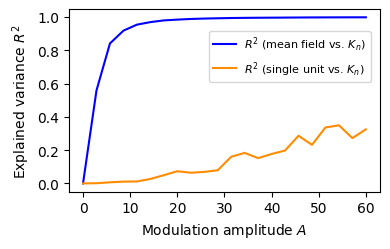

In [6]:
A_values = np.linspace(0, 60, 22)
omega = 2 * np.pi / 2000

r2_mean_arr = np.zeros_like(A_values, dtype=float)
r2_single_arr = np.zeros_like(A_values, dtype=float)

for idx, A in enumerate(A_values):
    mod_fn = lambda n, A=A: K_sinusoid(n, K0=K0, A=A, omega=omega)
    M_series, single_series, _ = simulate_mean_and_unit(
        mod_fn, N=N, T=T, discard=discard,
        K0=K0, r_min=r_min, r_max=r_max, seed=SEED + idx)
    K_series = np.array([mod_fn(n) for n in range(T)])[discard:]
    Xd = K_series.reshape(-1, 1)
    model_mean = LinearRegression().fit(Xd, M_series)
    model_single = LinearRegression().fit(Xd, single_series)
    r2_mean_arr[idx] = r2_score(M_series, model_mean.predict(Xd))
    r2_single_arr[idx] = r2_score(single_series, model_single.predict(Xd))

plt.figure(figsize=(4, 2.6))
plt.plot(A_values, r2_mean_arr, color='blue', linestyle='-',
         label=r'$R^2$ (mean field vs. $K_n$)')
plt.plot(A_values, r2_single_arr, color='darkorange', linestyle='-',
         label=r'$R^2$ (single unit vs. $K_n$)')
plt.xlabel('Modulation amplitude $A$')
plt.ylabel(r'Explained variance $R^2$')
plt.legend(loc=(0.45, 0.6), fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig2a.png'), dpi=300)
plt.show()

## Figure 2B — R² and SNR (M → x)

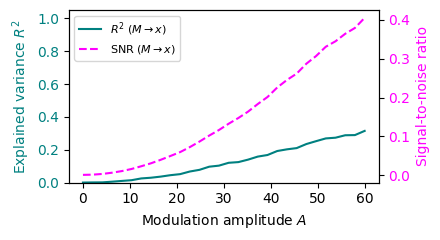

In [7]:
A_values2 = np.linspace(0, 60, 30)
r2_list = np.zeros_like(A_values2, dtype=float)
snr_list = np.zeros_like(A_values2, dtype=float)

for idx, A in enumerate(A_values2):
    mod_fn = lambda n, A=A: K_sinusoid(n, K0=K0, A=A)
    X_all, _ = simulate_full_population(mod_fn, N=N, T=T, K0=K0,
                                        r_min=r_min, r_max=r_max, seed=SEED)
    X_all = X_all[:, discard:]
    M_n = X_all.mean(axis=0)
    xi = X_all[0, :]
    X_design = M_n.reshape(-1, 1)
    model = LinearRegression().fit(X_design, xi)
    xi_hat = model.predict(X_design)
    r2_list[idx] = r2_score(xi, xi_hat)
    signal_var = np.var(M_n)
    residual_var = np.var(xi - xi_hat)
    snr_list[idx] = signal_var / residual_var if residual_var > 0 else np.inf

fig, ax1 = plt.subplots(figsize=(4.5, 2.5))
color_r2 = 'teal'; color_snr = 'magenta'
ax1.set_xlabel('Modulation amplitude $A$')
ax1.set_ylabel('Explained variance $R^2$', color=color_r2)
ax1.plot(A_values2, r2_list, color=color_r2, label='$R^2$ ($M\\rightarrow x$)')
ax1.tick_params(axis='y', labelcolor=color_r2)
ax1.set_ylim(0, 1.05)
ax2 = ax1.twinx()
ax2.set_ylabel('Signal-to-noise ratio', color=color_snr)
ax2.plot(A_values2, snr_list, color=color_snr, label='SNR ($M\\rightarrow x$)', ls='--')
ax2.tick_params(axis='y', labelcolor=color_snr)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'fig2b.png'), dpi=300)
plt.show()

## Figure 3 — Surrogate TE x₀ → x_j

A=0:  0/50 significant
A=25: 39/50 significant


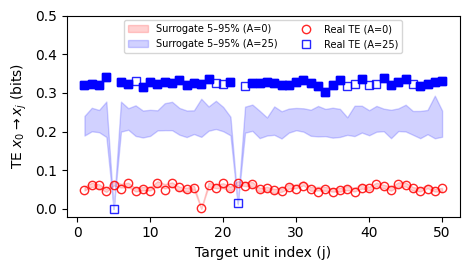

In [8]:
nsurr = 100; delta = 0.01

def simulate_uncoupled(A=0, seed=None):
    mod_fn = lambda n, A=A: K_sinusoid(n, K0=K0, A=A, omega=2*np.pi/2000)
    X_all, _ = simulate_full_population(mod_fn, N=N, T=T, K0=K0,
                                        r_min=r_min, r_max=r_max, seed=seed)
    return X_all[:, discard:]

def compute_te_profile(A, max_targets, n_surrogates=nsurr, seed=None):
    X_all = simulate_uncoupled(A=A, seed=seed)
    x0 = X_all[0]
    real_te, pvals, surr_p05, surr_p95 = [], [], [], []
    for j in range(1, max_targets + 1):
        xj = X_all[j]
        te_obs = transfer_entropy_lagged(x0, xj)
        te_surr = surrogate_te_array(x0, xj, n_surrogates=n_surrogates,
                                     seed=None if seed is None else seed + j)
        real_te.append(te_obs)
        pvals.append(empirical_p_value(te_obs, te_surr))
        surr_p05.append(np.percentile(te_surr, 5))
        surr_p95.append(np.percentile(te_surr, 95))
    return np.array(real_te), np.array(pvals), np.array(surr_p05), np.array(surr_p95)

max_targets = 50
real_te_0,  p_0,  s05_0,  s95_0  = compute_te_profile(A=0,  max_targets=max_targets, seed=SEED)
real_te_25, p_25, s05_25, s95_25 = compute_te_profile(A=25, max_targets=max_targets, seed=SEED)
x_vals = np.arange(1, max_targets + 1)
sig_0 = p_0 < delta; sig_25 = p_25 < delta
print(f'A=0:  {np.sum(sig_0)}/{len(sig_0)} significant')
print(f'A=25: {np.sum(sig_25)}/{len(sig_25)} significant')

plt.figure(figsize=(4.8, 2.8))
plt.fill_between(x_vals, s05_0,  s95_0,  color='red',  alpha=0.18, label='Surrogate 5–95% (A=0)')
plt.fill_between(x_vals, s05_25, s95_25, color='blue', alpha=0.18, label='Surrogate 5–95% (A=25)')
plt.plot(x_vals, real_te_0,  'o', mfc='none', color='red',  label='Real TE (A=0)',  alpha=0.85)
plt.plot(x_vals, real_te_25, 's', mfc='none', color='blue', label='Real TE (A=25)', alpha=0.85)
plt.plot(x_vals[sig_0],  real_te_0[sig_0],  'o', color='red',  lw=0)
plt.plot(x_vals[sig_25], real_te_25[sig_25], 's', color='blue', lw=0)
plt.xlabel('Target unit index (j)', fontsize=10)
plt.ylabel(r'TE $x_0 \rightarrow x_j$ (bits)', fontsize=10)
plt.legend(loc='upper center', ncol=2, fontsize=7)
plt.ylim(-0.02, 0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig3.png'), dpi=300)
plt.show()

## Figure S1 — TE vs embedding lag k

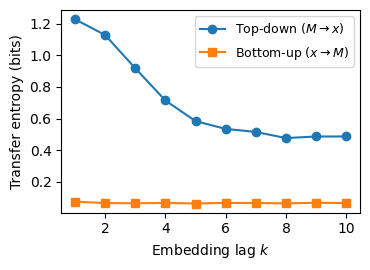

In [9]:
A_val = 25; lags = np.arange(1, 11)
te_td_seeds_s1 = np.zeros((n_seeds, len(lags)))
te_bu_seeds_s1 = np.zeros((n_seeds, len(lags)))
mod_fn_s1 = lambda n: K_sinusoid(n, K0=K0, A=A_val)
for s in range(n_seeds):
    M, X, _ = simulate_mean_and_unit(mod_fn_s1, N=N, T=T, discard=discard,
                                     K0=K0, r_min=r_min, r_max=r_max, seed=SEED + s)
    for j, k in enumerate(lags):
        te_td_seeds_s1[s, j] = transfer_entropy_lagged(M, X, k=k, bins=BINS_DEFAULT)
        te_bu_seeds_s1[s, j] = transfer_entropy_lagged(X, M, k=k, bins=BINS_DEFAULT)

plt.figure(figsize=(3.8, 2.8))
plt.plot(lags, te_td_seeds_s1.mean(axis=0), 'o-', label=r'Top-down ($M\rightarrow x$)')
plt.plot(lags, te_bu_seeds_s1.mean(axis=0), 's-', label=r'Bottom-up ($x\rightarrow M$)')
plt.xlabel('Embedding lag $k$')
plt.ylabel('Transfer entropy (bits)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'figS1.png'), dpi=300)
plt.show()

## Figure S2 — Logistic + inverse logistic modulation

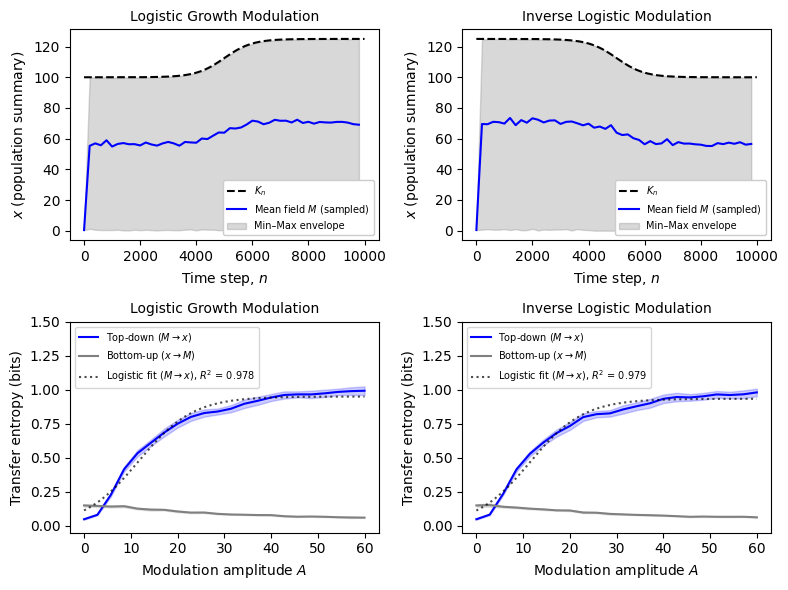

In [10]:
n0 = 5000; k_shape = 0.002; A_demo = 25; sample_every = 200
A_vals_s2 = np.linspace(0, 60, 22); n_reps = 10; lag_k = LAG_K_DEFAULT

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

for col, (mod_type, mod_func) in enumerate([
    ('Logistic Growth', K_logistic), ('Inverse Logistic', K_invlogistic)
]):
    # Top row: time series
    mod_fn_demo = lambda n, mf=mod_func: mf(n, K0=K0, A=A_demo, k=k_shape, n0=n0)
    X_all_s2, K_t_s2 = simulate_full_population(
        mod_fn_demo, N=N, T=T, K0=K0, r_min=r_min, r_max=r_max, seed=SEED)
    si = np.arange(0, T, sample_every)
    Xs = X_all_s2[:, si]
    ax_ts = axes[0, col]
    ax_ts.plot(np.arange(T), K_t_s2, color='black', lw=1.5, ls='--', label=r'$K_n$')
    ax_ts.plot(si, Xs.mean(axis=0), '-', color='blue', label=r'Mean field $M$ (sampled)')
    ax_ts.fill_between(si, Xs.min(axis=0), Xs.max(axis=0),
                       color='gray', alpha=0.3, label='Min–Max envelope')
    ax_ts.set_xlabel('Time step, $n$'); ax_ts.set_ylabel('$x$ (population summary)')
    ax_ts.set_title(f'{mod_type} Modulation', fontsize=10)
    ax_ts.legend(loc='lower right', fontsize=7, facecolor='white', framealpha=1)

    # Bottom row: TE sweep
    te_td_s2, te_bu_s2 = [], []
    for A in A_vals_s2:
        td_r, bu_r = [], []
        mod_fn_A = lambda n, A=A, mf=mod_func: mf(n, K0=K0, A=A, k=k_shape, n0=n0)
        for rep in range(n_reps):
            M, X, _ = simulate_mean_and_unit(
                mod_fn_A, N=N, T=T, discard=discard,
                K0=K0, r_min=r_min, r_max=r_max, seed=SEED + rep)
            td_r.append(transfer_entropy_lagged(M, X, k=lag_k, bins=BINS_DEFAULT))
            bu_r.append(transfer_entropy_lagged(X, M, k=lag_k, bins=BINS_DEFAULT))
        te_td_s2.append(td_r); te_bu_s2.append(bu_r)

    tdm, tdc = zip(*[mean_ci(v) for v in te_td_s2])
    bum, buc = zip(*[mean_ci(v) for v in te_bu_s2])
    tdm = np.array(tdm); tdc = np.array(tdc)
    bum = np.array(bum); buc = np.array(buc)
    popt_s2, R2_s2 = fit_logistic_and_r2(A_vals_s2, tdm,
                                          p0=[max(0.1, tdm.max()), 0.1, 20.0])

    ax_te = axes[1, col]
    ax_te.plot(A_vals_s2, tdm, label=r'Top-down ($M\rightarrow x$)', color='blue')
    ax_te.fill_between(A_vals_s2, tdm - tdc, tdm + tdc, color='blue', alpha=0.2)
    ax_te.plot(A_vals_s2, bum, label=r'Bottom-up ($x\rightarrow M$)', color='gray')
    ax_te.fill_between(A_vals_s2, bum - buc, bum + buc, color='gray', alpha=0.2)
    Af = np.linspace(0, 60, 300)
    ax_te.plot(Af, logistic_curve(Af, *popt_s2), color='black', ls=':', alpha=0.7,
              label=f'Logistic fit ($M\\rightarrow x$), $R^2$ = {R2_s2:.3f}')
    ax_te.set_xlabel('Modulation amplitude $A$')
    ax_te.set_ylabel('Transfer entropy (bits)')
    ax_te.set_title(f'{mod_type} Modulation', fontsize=10)
    ax_te.legend(loc='upper left', fontsize=7)
    ax_te.set_ylim(-0.05, 1.5)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'figS2.png'), dpi=300)
plt.show()

## Figure S3 — Return maps (A = {0, 20, 40, 60})

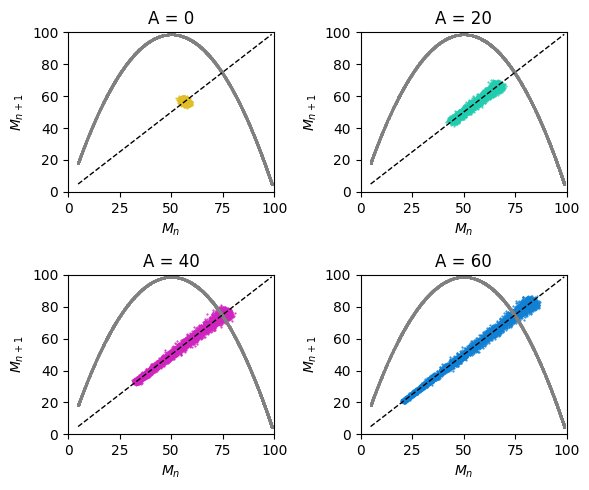

In [11]:
A_values_s3 = [0, 20, 40, 60]
colors_s3 = ['#E1BE25', '#22CCAF', '#D024BF', '#1080D5']

fig, axes = plt.subplots(2, 2, figsize=(6, 5))
axes = axes.flatten()

for idx, A in enumerate(A_values_s3):
    ax = axes[idx]
    rng = np.random.default_rng(SEED + idx)
    x = np.full(N, 0.1)
    r = rng.uniform(r_min, r_max, N)
    M_n, M_np1 = [], []
    for t in range(T):
        K_t_val  = K_sinusoid(t,   K0=K0, A=A, omega=2*np.pi/2000)
        K_t1_val = K_sinusoid(t+1, K0=K0, A=A, omega=2*np.pi/2000)
        if t >= discard:
            mean_x_t = np.mean(x)
            x_next_map = logistic_step(x, r, K_t1_val)
            M_n.append(mean_x_t)
            M_np1.append(np.mean(x_next_map))
        x_new = logistic_step(x, r, K_t_val)
        x = np.clip(x_new, 0, 2 * K0)

    ax.scatter(M_n, M_np1, color=colors_s3[idx], s=0.25, alpha=1.0)
    # Single-unit logistic reference
    x_single = 1.0; r_single = 3.95; xv, yv = [], []
    for t in range(T):
        x_next = logistic_step(x_single, r_single, K0)
        if t >= discard: xv.append(x_single); yv.append(x_next)
        x_single = np.clip(x_next, 0, 2 * K0)
    ax.scatter(xv, yv, color='gray', s=0.25, alpha=0.8)
    all_vals = M_n + M_np1 + xv + yv
    vmin, vmax = min(all_vals), max(all_vals)
    ax.plot([vmin, vmax], [vmin, vmax], ls='--', color='black', linewidth=1)
    ax.set_title(f'A = {A}')
    ax.set_xlabel(r'$M_n$'); ax.set_ylabel(r'$M_{n+1}$')
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'figS3.png'), dpi=300)
plt.show()

## Summary

In [12]:
print('=== CTE Summary ===')
print(f'At A=0:  TE(M->x)={td_unc_m[0]:.4f}, CTE(M->x|K)={td_cte_m[0]:.4f}')
print(f'At A=30: TE(M->x)={td_unc_m[11]:.4f}, CTE(M->x|K)={td_cte_m[11]:.4f}')
print(f'At A=60: TE(M->x)={td_unc_m[-1]:.4f}, CTE(M->x|K)={td_cte_m[-1]:.4f}')
print(f'Max CTE(M->x|K) = {td_cte_m.max():.4f}')
print(f'Max CTE(x->M|K) = {bu_cte_m.max():.4f}')
ratio = td_cte_m[-1] / td_unc_m[-1] if td_unc_m[-1] > 0 else 0
print(f'CTE/TE at A=60: {ratio:.3f}  (reduction: {(1-ratio)*100:.1f}%)')
print()
print('=== Omega sweep ===')
for p, te in zip(omega_periods, te_omega_td):
    print(f'  Period={p:.0f}, TE(M->x)={te:.4f}')
print()
print('All figures saved to:', FIGDIR)

=== CTE Summary ===
At A=0:  TE(M->x)=0.0491, CTE(M->x|K)=0.0491
At A=30: TE(M->x)=1.1810, CTE(M->x|K)=0.1182
At A=60: TE(M->x)=1.1008, CTE(M->x|K)=0.0966
Max CTE(M->x|K) = 0.3637
Max CTE(x->M|K) = 0.6811
CTE/TE at A=60: 0.088  (reduction: 91.2%)

=== Omega sweep ===
  Period=10000, TE(M->x)=1.1109
  Period=5000, TE(M->x)=1.1380
  Period=2000, TE(M->x)=1.1290
  Period=1000, TE(M->x)=1.0242
  Period=500, TE(M->x)=0.8991
  Period=200, TE(M->x)=0.5425
  Period=100, TE(M->x)=0.1397

All figures saved to: /Users/celia/VSCode/macro_to_micro/figures
